In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [3]:
#load data
df = pd.read_csv("D:/other/gold_prices_monthly.csv", delimiter=";")

# Menampilkan nama kolom dan beberapa baris pertama
print("Nama kolom dalam data:", df.columns)
print("\nData awal:")
print(df.head())


Nama kolom dalam data: Index(['Date', 'Price', 'Oil_Price', 'Inflation'], dtype='object')

Data awal:
         Date        Price  Oil_Price  Inflation
0  01/01/2010  1083.000000  72.889999    216.687
1  01/02/2010  1118.300049  79.660004    216.741
2  01/03/2010  1113.300049  83.760002    217.631
3  01/04/2010  1180.099976  86.150002    218.009
4  01/05/2010  1212.199951  73.970001    218.178


In [4]:
# Convert the 'Price' column to numeric
df['Price'] = df['Price'].astype(float)

In [5]:
# Load the dataset (assuming 'df' is your DataFrame)
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')  # Convert to datetime
df['Year'] = df['Date'].dt.year  # Extract year

In [6]:
# Menentukan periode moving average
periode = 3

In [7]:
# Menghitung Moving Average untuk Harga Emas
df['SMA_Emas'] = df['Price'].rolling(window=periode).mean()  # SMA

In [8]:
# Determine future prediction years
future_years = list(range(df['Year'].max() + 1, 2041))

In [9]:
# Mengambil nilai terakhir SMA
last_sma = df['SMA_Emas'].dropna().iloc[-1]  # Mengambil nilai terakhir yang valid


In [10]:
# Membuat prediksi menggunakan nilai terakhir SMA
predicted_prices_sma = [last_sma] * len(future_years)


In [11]:
# Create a DataFrame for future predictions
future_data = pd.DataFrame({
    'Year': future_years,
    'Prediksi_SMA': predicted_prices_sma
})

In [12]:
# Combine historical and future data
df_combined = pd.concat([df[['Year', 'Price', 'SMA_Emas']], future_data.rename(columns={'Prediksi_SMA': 'SMA_Emas'})], ignore_index=True)

In [13]:
# Calculate evaluation metrics on the historical SMA
# Only compare non-NaN SMA values with corresponding actual prices
actual_prices = df['Price'][periode - 1:]  # Skip the first rows without SMA
sma_values = df['SMA_Emas'][periode - 1:]

mse = mean_squared_error(actual_prices, sma_values)  # Mean Squared Error
mae = mean_absolute_error(actual_prices, sma_values)  # Mean Absolute Error (MAP)
mape = np.mean(np.abs((actual_prices - sma_values) / actual_prices)) * 100  # Mean Absolute Percentage Error

In [14]:
# Display metrics
print("\nEvaluation Metrics:")
print(f"Mean Absolute Error (MAP): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Display combined historical and predicted data
print("\nCombined Historical and Predicted Data:")
print(df_combined.tail())


Evaluation Metrics:
Mean Absolute Error (MAP): 42.38169976906318
Mean Squared Error (MSE): 2979.836491008884
Mean Absolute Percentage Error (MAPE): 2.71%

Combined Historical and Predicted Data:
     Year  Price  SMA_Emas
165  2036    NaN    2685.0
166  2037    NaN    2685.0
167  2038    NaN    2685.0
168  2039    NaN    2685.0
169  2040    NaN    2685.0


In [15]:
# Optional: Save the combined data to a CSV file
#df_combined.to_csv("D:/other/gold/combined_gold_predictions 1.csv", index=False)

In [16]:
# Replace NaN values in the entire DataFrame with 0
df.fillna(0, inplace=True)

# Optionally, you can replace NaN values in specific columns
# Example: Replace NaN in 'SMA_Emas' with 0
df['SMA_Emas'].fillna(0, inplace=True)

# Display the updated DataFrame
print("DataFrame after replacing NaN:")
print(df.tail())


DataFrame after replacing NaN:
          Date        Price  Oil_Price  Inflation  Year     SMA_Emas
150 2024-07-01  2426.500000  77.910004        0.0  2024  2359.033284
151 2024-08-01  2493.800049  73.550003        0.0  2024  2416.000000
152 2024-10-01  2738.300049  69.260002        0.0  2024  2552.866699
153 2024-11-01  2657.000000  68.000000        0.0  2024  2629.700033
154 2025-01-01  2659.699951  74.790001        0.0  2025  2685.000000


C:\Users\revid\AppData\Local\Temp\ipykernel_17984\1139764394.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['SMA_Emas'].fillna(0, inplace=True)


In [17]:
# Kalkulasi metrik evaluasi per tahun
evaluation_results = []

# Iterasi untuk setiap tahun
for year in df['Year'].unique():
    actual = df[df['Year'] == year]['Price']  # Ganti 'Actual' dengan kolom data aktual
    predicted = df[df['Year'] == year]['SMA_Emas']  # Ganti 'Predicted' dengan kolom data prediksi

    # Hitung metrik evaluasi
    mse = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100  # Mean Absolute Percentage Error (MAPE)

    # Tambahkan hasil ke daftar
    evaluation_results.append({
        'Year': year,
        'MSE': mse,
        'MAE': mae,
        'MAPE (%)': mape
    })

# Buat DataFrame hasil evaluasi
evaluation_df = pd.DataFrame(evaluation_results)

# Tampilkan tabel hasil evaluasi
print("Tabel Hasil Evaluasi:")
print(evaluation_df)


Tabel Hasil Evaluasi:
    Year            MSE         MAE   MAPE (%)
0   2010  221933.130065  233.336367  20.772024
1   2011    6160.494744   61.699996   3.823353
2   2012    2441.744203   39.770368   2.375526
3   2013    5128.167185   58.816667   4.308216
4   2014     897.739211   23.387906   1.892351
5   2015    1301.968658   28.055556   2.422850
6   2016    2241.741585   39.390906   3.192297
7   2017     778.981131   22.353337   1.758464
8   2018     790.805085   23.100000   1.846497
9   2019    1716.421648   34.593331   2.448065
10  2020    4360.928710   57.746664   3.210899
11  2021    2582.765700   38.872721   2.166133
12  2022    3321.685841   51.703018   2.889420
13  2023    3649.357867   50.636666   2.574162
14  2024    7230.572963   64.520007   2.640262
15  2025     640.092479   25.300049   0.951237


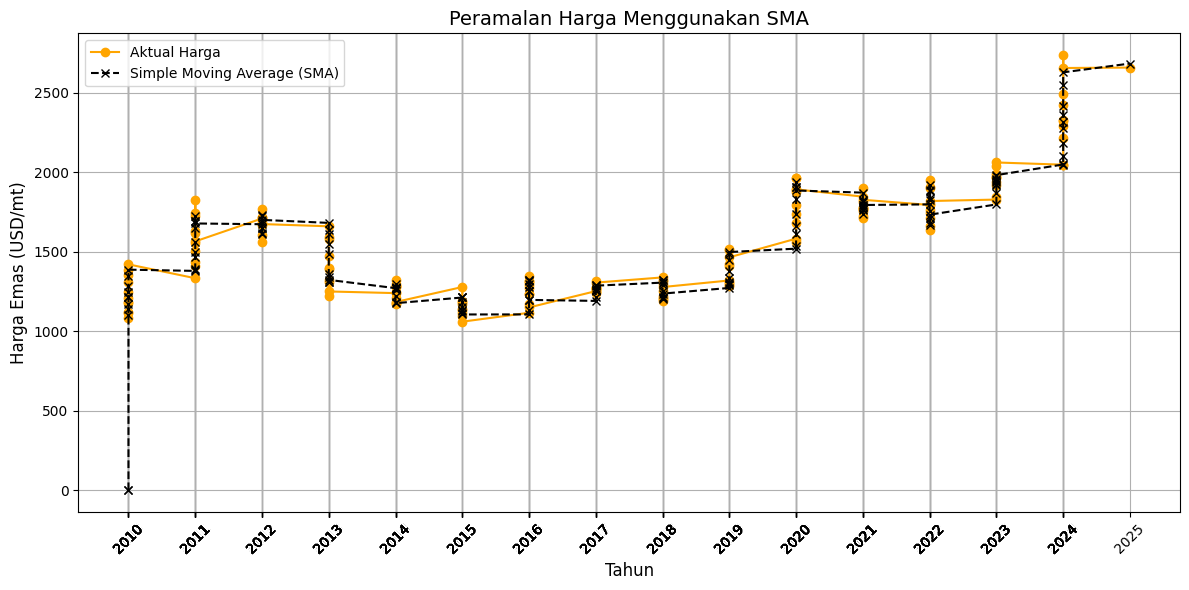

In [18]:
# Filter hanya data yang tidak mengandung NaN untuk plot yang lebih bersih
df_clean = df.dropna(subset=['Price', 'SMA_Emas'])

# Plot hasil
plt.figure(figsize=(12, 6))

# Plot data harga aktual
plt.plot(
    df_clean['Year'], 
    df_clean['Price'], 
    label='Aktual Harga', 
    color='orange', 
    marker='o', 
    linestyle='-'
)

# Plot data prediksi SMA
plt.plot(
    df_clean['Year'], 
    df_clean['SMA_Emas'], 
    label='Simple Moving Average (SMA)', 
    color='black', 
    marker ='x',
    linestyle='--'
)

# Atur judul dan label
plt.title('Peramalan Harga Menggunakan SMA', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga Emas (USD/mt)', fontsize=12)
plt.xticks(ticks=df_clean['Year'], rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()


# Atur layout agar lebih rapi
plt.tight_layout()

# Tampilkan plot
plt.show()